In [1]:
#IR spectra of solvents multiplied by a percentage (0.3)
#The calibration curve also multipled by the remaining to fill the spectra (0.7)
#Use hyperparameter to do this with ease.
#MAE with PLS regression to see the accuracy in prediciton of each syntheically contaminated calibration curve.
#Run multiple contiminated calibration curves to see which gives us the best predicted value 
#based on the standard of our original calibration curve which is probably contaminated.

Loaded 33 calibration spectra
Loaded 4 solvent spectra
Augmented dataset size: 561

Predictions:
                          file      solvent  prediction
0        YH_2025_002_DCE_A.CSV          DCE    0.530944
1        YH_2025_002_DCE_B.CSV          DCE    0.580330
2        YH_2025_002_DCE_C.CSV          DCE    0.604574
3   YH_2025_002_DMSOtest_A.CSV  DMSO_rewash    0.965105
4   YH_2025_002_DMSOtest_B.CSV  DMSO_rewash    0.961122
5   YH_2025_002_DMSOtest_C.CSV  DMSO_rewash    0.949245
6       YH_2025_002_HFIP_A.CSV         HFIP    0.226944
7       YH_2025_002_HFIP_B.CSV         HFIP    0.264776
8       YH_2025_002_HFIP_C.CSV         HFIP    0.203466
9    YH_2025_002_Toluene_A.CSV      Toluene    0.498532
10   YH_2025_002_Toluene_B.CSV      Toluene    0.511113
11   YH_2025_002_Toluene_C.CSV      Toluene    0.490980
12      YH_2025_002_DMSO_A.CSV  DMSO_rewash    1.028381
13      YH_2025_002_DMSO_B.CSV  DMSO_rewash    0.966283
14      YH_2025_002_DMSO_C.CSV  DMSO_rewash    0.983537

Averag

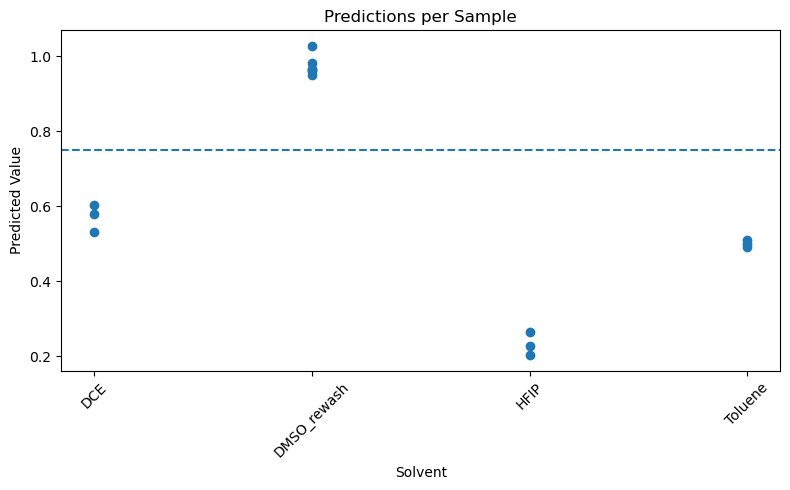

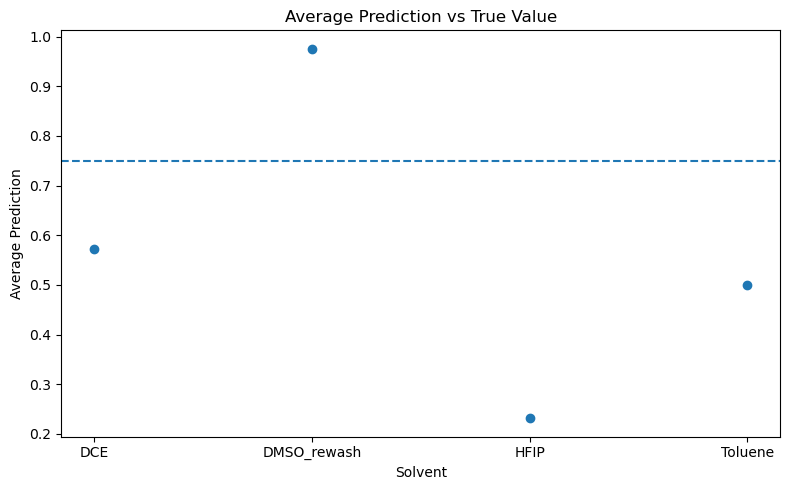

In [28]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error

root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dirs = [
    '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_002_DMSO Re-Wash/',
    '/Users/yoelhan/Documents/ChemResearch/ir_data/Original DMSO/'
]

calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])[:33]

y_values = [
    0.1,0.1,0.1,0,0,0,1,1,1,0.9,0.9,0.9,
    0.8,0.8,0.8,0.7,0.7,0.7,0.6,0.6,0.6,
    0.5,0.5,0.5,0.4,0.4,0.4,0.3,0.3,0.3,
    0.2,0.2,0.2
]

def load_spectrum(path):
    data = pd.read_csv(path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def synthesize(x, solvent, alpha):
    return x + alpha * solvent

rows = []
for f, y_val in zip(calib_files, y_values):
    spec = load_spectrum(os.path.join(root_calib, f))
    rows.append(np.insert(spec, 0, y_val))

min_len = min(len(r) for r in rows)
rows = [r[:min_len] for r in rows]

df = pd.DataFrame(rows, columns=['y'] + [f'x{i}' for i in range(min_len-1)])

y_calib = df['y'].values
X_calib = df.drop('y', axis=1).values
n_features = X_calib.shape[1]

print(f"Loaded {len(X_calib)} calibration spectra")

# LOAD SOLVENTS
solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

solvents = {}
for file in solvent_files:
    spec = load_spectrum(os.path.join(solvent_dir, file))
    
    if len(spec) != n_features:
        spec = np.interp(np.linspace(0,1,n_features),
                         np.linspace(0,1,len(spec)), spec)
    
    solvents[file.split('.')[0]] = spec

print(f"Loaded {len(solvents)} solvent spectra")


# SYNTHETIC AUGMENTATION
alphas = np.arange(0.1, 0.5, 0.1)

X_all = [X_calib]
y_all = [y_calib]

for solvent_spec in solvents.values():
    for alpha in alphas:
        X_syn = np.array([synthesize(x, solvent_spec, alpha) for x in X_calib])
        X_all.append(X_syn)
        y_all.append(y_calib)

X_all = np.vstack(X_all)
y_all = np.concatenate(y_all)

print(f"Augmented dataset size: {len(X_all)}")


# TRAIN MODEL
pls = PLSRegression(n_components=5)
pls.fit(X_all, y_all)


# TESTING + LABELING
results = []

for test_dir in test_dirs:
    test_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith('.csv')])
    
    for f in test_files:
        spec = load_spectrum(os.path.join(test_dir, f))[:n_features]
        pred = float(pls.predict(spec.reshape(1, -1))[0])
        
        # assign solvent label
        if 'DCE' in f:
            label = 'DCE'
        elif 'HFIP' in f:
            label = 'HFIP'
        elif 'Toluene' in f:
            label = 'Toluene'
        elif 'DMSO' in f and 'Re' in test_dir:
            label = 'DMSO_rewash'
        else:
            label = 'DMSO_original'
        
        results.append({
            'file': f,
            'solvent': label,
            'prediction': pred
        })

results_df = pd.DataFrame(results)

print("\nPredictions:")
print(results_df)


# TRUE VALUE COMPARISON
true_value = 0.75

avg_predictions = results_df.groupby('solvent')['prediction'].mean()

comparison = pd.DataFrame({
    'Avg Prediction': avg_predictions,
    'True Value': true_value,
    'Error': avg_predictions - true_value,
    'Abs Error': abs(avg_predictions - true_value)
})

print("\nAverage Prediction per Solvent:")
print(avg_predictions)

print("\nComparison vs True Value (0.75):")
print(comparison)

mae = np.mean(np.abs(avg_predictions - true_value))
print(f"\nMAE vs 0.75: {mae:.4f}")

plt.figure(figsize=(8,5))
plt.scatter(results_df['solvent'], results_df['prediction'])
plt.axhline(true_value, linestyle='--')
plt.xlabel('Solvent')
plt.ylabel('Predicted Value')
plt.title('Predictions per Sample')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.scatter(avg_predictions.index, avg_predictions.values)
plt.axhline(true_value, linestyle='--')
plt.xlabel('Solvent')
plt.ylabel('Average Prediction')
plt.title('Average Prediction vs True Value')
plt.tight_layout()
plt.show()

Loaded 33 calibration spectra with 7467 features each.
Interpolated YH_2025_007_DEE.csv to 7467 points
Interpolated YH_2025_007_DMSO.csv to 7467 points
Interpolated YH_2025_007_IPA.csv to 7467 points
Interpolated YH_2025_007_Water.csv to 7467 points
Loaded 4 solvent spectra.

Generating synthetic calibration data for YH_2025_007_DEE...
Generating synthetic calibration data for YH_2025_007_DMSO...
Generating synthetic calibration data for YH_2025_007_IPA...
Generating synthetic calibration data for YH_2025_007_Water...
Calibration dataset expanded to 561 samples (≈ 17× original with solvent contamination).

Testing 15 files...

Prediction for YH_2025_002_DCE_A.CSV: y = 0.5309
Prediction for YH_2025_002_DCE_B.CSV: y = 0.5803
Prediction for YH_2025_002_DCE_C.CSV: y = 0.6046
Prediction for YH_2025_002_DMSOtest_A.CSV: y = 0.9651
Prediction for YH_2025_002_DMSOtest_B.CSV: y = 0.9611
Prediction for YH_2025_002_DMSOtest_C.CSV: y = 0.9492
Prediction for YH_2025_002_HFIP_A.CSV: y = 0.2269
Predic

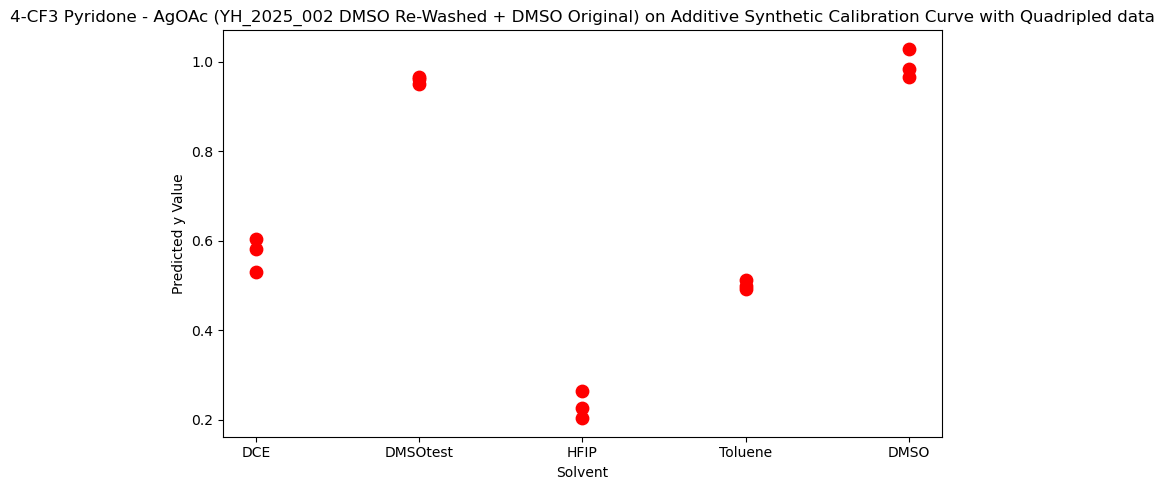

In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error

root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dirs = [
    '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_002_DMSO Re-Wash/',
    '/Users/yoelhan/Documents/ChemResearch/ir_data/Original DMSO/'
]

calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])[:33]
y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

alphas = np.arange(0.1, 0.5, 0.1)
n_components = 5

def load_spectrum(file_path):
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def synthesize_spectrum(calib, solvent, alpha):
    return calib + alpha * solvent

calib_rows = []
for file, y_val in zip(calib_files, y_values):
    path = os.path.join(root_calib, file)
    spectrum = load_spectrum(path)
    row = np.insert(spectrum, 0, y_val)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]
columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(calib_rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values
n_samples, n_features = X_calib.shape
print(f"Loaded {n_samples} calibration spectra with {n_features} features each.")

solvents = {}
for file in solvent_files:
    path = os.path.join(solvent_dir, file)
    spec = load_spectrum(path)
    if len(spec) != n_features:
        spec = np.interp(np.linspace(0, 1, n_features), np.linspace(0, 1, len(spec)), spec)
        print(f"Interpolated {file} to {n_features} points")
    else:
        print(f"{file} loaded without interpolation")
    solvents[file.split('.')[0]] = spec

print(f"Loaded {len(solvents)} solvent spectra.\n")

X_augmented = [X_calib]
y_augmented = [y_calib]

for solvent_name, solvent_spec in solvents.items():
    print(f"Generating synthetic calibration data for {solvent_name}...")
    for alpha in alphas:
        X_synth = np.array([synthesize_spectrum(x_row, solvent_spec, alpha) for x_row in X_calib])
        X_augmented.append(X_synth)
        y_augmented.append(y_calib)

X_calib_all = np.vstack(X_augmented)
y_calib_all = np.concatenate(y_augmented)

print(f"Calibration dataset expanded to {len(X_calib_all)} samples "
      f"(≈ {len(solvents) * len(alphas) + 1}× original with solvent contamination).\n")

pls = PLSRegression(n_components=n_components)
pls.fit(X_calib_all, y_calib_all)

results = []
total_test_files = []
for test_dir in test_dirs:
    test_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith('.csv')])
    total_test_files += [(test_dir, f) for f in test_files]

print(f"Testing {len(total_test_files)} files...\n")

for test_dir, test_file in total_test_files:
    test_path = os.path.join(test_dir, test_file)
    test_spec = load_spectrum(test_path)[:n_features]
    y_pred = float(pls.predict(test_spec.reshape(1, -1))[0])
    results.append({'test_file': test_file, 'y_pred': y_pred})
    print(f"Prediction for {test_file}: y = {y_pred:.4f}")

pd.DataFrame(results).to_csv('synthetic_quadruple_additive_results_with_DMSO.csv', index=False)
print("\nFull results saved to synthetic_quadruple_additive_results_with_DMSO.csv")

solvents = ['DCE', 'DMSOtest', 'HFIP', 'Toluene', 'DMSO']
y_values = [r['y_pred'] for r in results]

x_positions = np.repeat(np.arange(len(solvents)), 3)

plt.figure(figsize=(8, 5))
plt.scatter(x_positions, y_values, color='red', s=80)

plt.xticks(ticks=np.arange(len(solvents)), labels=solvents)
plt.xlabel('Solvent')
plt.ylabel('Predicted y Value')
plt.title('4-CF3 Pyridone - AgOAc (YH_2025_002 DMSO Re-Washed + DMSO Original) on Additive Synthetic Calibration Curve with Quadripled data')
plt.tight_layout()
plt.show()

Loaded 33 calibration spectra with 7467 features each.
Interpolated YH_2025_007_DEE.csv to 7467 points
Interpolated YH_2025_007_DMSO.csv to 7467 points
Interpolated YH_2025_007_IPA.csv to 7467 points
Interpolated YH_2025_007_Water.csv to 7467 points
Loaded 4 solvent spectra.

Calibration dataset expanded to 561 samples (~4× original with solvent contamination).

Group K-Fold CV MAEs per fold: [0.16236132263016909, 0.11223613477240128, 0.09373013366669154, 0.10152351964830603, 0.08475563056032183]
Mean CV MAE: 0.1109

Testing 12 files...

Prediction for YH_2025_002_DCE_A.CSV: y = 0.5309
Prediction for YH_2025_002_DCE_B.CSV: y = 0.5803
Prediction for YH_2025_002_DCE_C.CSV: y = 0.6046
Prediction for YH_2025_002_DMSOtest_A.CSV: y = 0.9651
Prediction for YH_2025_002_DMSOtest_B.CSV: y = 0.9611
Prediction for YH_2025_002_DMSOtest_C.CSV: y = 0.9492
Prediction for YH_2025_002_HFIP_A.CSV: y = 0.2269
Prediction for YH_2025_002_HFIP_B.CSV: y = 0.2648
Prediction for YH_2025_002_HFIP_C.CSV: y = 0.20

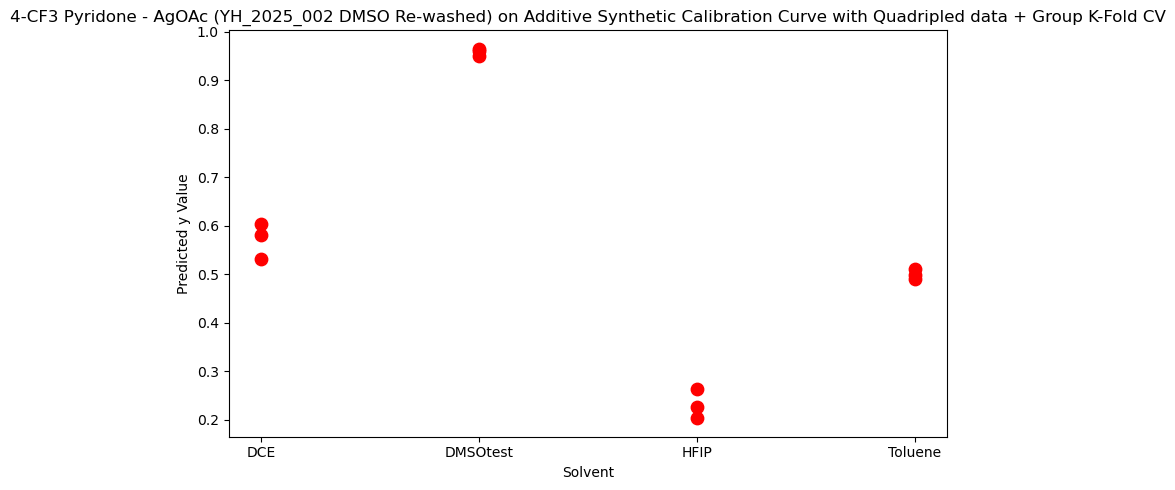

In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GroupKFold

root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_002_DMSO Re-Wash/'

calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])[:33]
y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

alphas = np.arange(0.1, 0.5, 0.1)
n_components = 5
k_folds = 5

def load_spectrum(file_path):
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def synthesize_spectrum(calib, solvent, alpha):
    return calib + alpha * solvent

calib_rows = []
for file, y_val in zip(calib_files, y_values):
    spectrum = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spectrum, 0, y_val)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]
columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(calib_rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values
n_samples, n_features = X_calib.shape
print(f"Loaded {n_samples} calibration spectra with {n_features} features each.")

solvents = {}
for file in solvent_files:
    spec = load_spectrum(os.path.join(solvent_dir, file))
    if len(spec) != n_features:
        spec = np.interp(np.linspace(0, 1, n_features),
                         np.linspace(0, 1, len(spec)), spec)
        print(f"Interpolated {file} to {n_features} points")
    solvents[file.split('.')[0]] = spec

print(f"Loaded {len(solvents)} solvent spectra.\n")

X_augmented = [X_calib]
y_augmented = [y_calib]
group_labels = [np.arange(len(y_calib))]

for solvent_spec in solvents.values():
    for alpha in alphas:
        X_synth = np.array([synthesize_spectrum(x_row, solvent_spec, alpha) for x_row in X_calib])
        X_augmented.append(X_synth)
        y_augmented.append(y_calib)
        group_labels.append(np.arange(len(y_calib)))

X_calib_all = np.vstack(X_augmented)
y_calib_all = np.concatenate(y_augmented)
groups = np.concatenate(group_labels)
print(f"Calibration dataset expanded to {len(X_calib_all)} samples (~4× original with solvent contamination).\n")

gkf = GroupKFold(n_splits=k_folds)
cv_mae = []

for train_idx, val_idx in gkf.split(X_calib_all, y_calib_all, groups):
    pls = PLSRegression(n_components=n_components)
    pls.fit(X_calib_all[train_idx], y_calib_all[train_idx])
    y_val_pred = pls.predict(X_calib_all[val_idx])
    cv_mae.append(mean_absolute_error(y_calib_all[val_idx], y_val_pred))

print(f"Group K-Fold CV MAEs per fold: {cv_mae}")
print(f"Mean CV MAE: {np.mean(cv_mae):.4f}\n")

pls_final = PLSRegression(n_components=n_components)
pls_final.fit(X_calib_all, y_calib_all)

test_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith('.csv')])
print(f"Testing {len(test_files)} files...\n")

results = []
predictions = []

for test_file in test_files:
    test_spec = load_spectrum(os.path.join(test_dir, test_file))[:n_features]
    y_pred = float(pls_final.predict(test_spec.reshape(1, -1))[0])
    predictions.append((test_file, y_pred))
    results.append({'test_file': test_file, 'y_pred': y_pred})
    print(f"Prediction for {test_file}: y = {y_pred:.4f}")

pd.DataFrame(results).to_csv('synthetic_quadruple_additive_groupkfold_results.csv', index=False)
print("\nFull results saved to synthetic_quadruple_additive_groupkfold_results.csv")

solvents = ['DCE', 'DMSOtest', 'HFIP', 'Toluene']
y_values = [p[1] for p in predictions]

x_positions = np.repeat(np.arange(len(solvents)), 3)

plt.figure(figsize=(8, 5))
plt.scatter(x_positions, y_values, color='red', s=80)

plt.xticks(ticks=np.arange(len(solvents)), labels=solvents)
plt.xlabel('Solvent')
plt.ylabel('Predicted y Value')
plt.title('4-CF3 Pyridone - AgOAc (YH_2025_002 DMSO Re-washed) on Additive Synthetic Calibration Curve with Quadripled data + Group K-Fold CV')
plt.tight_layout()
plt.show()

Loaded 33 calibration spectra with 7467 features each.
Interpolated YH_2025_007_DEE.csv to 7467 points
Interpolated YH_2025_007_DMSO.csv to 7467 points
Interpolated YH_2025_007_IPA.csv to 7467 points
Interpolated YH_2025_007_Water.csv to 7467 points
Loaded 4 solvent spectra.

Generating synthetic calibration data for YH_2025_007_DEE...
Generating synthetic calibration data for YH_2025_007_DMSO...
Generating synthetic calibration data for YH_2025_007_IPA...
Generating synthetic calibration data for YH_2025_007_Water...
Calibration dataset expanded to 561 samples (≈ 4× original with solvent contamination).

Testing 12 files...

Prediction for YH_2025_009_DEE_A.CSV: y = 0.6712, MAE = 0.128755
Prediction for YH_2025_009_DEE_B.CSV: y = 0.8277, MAE = 0.027684
Prediction for YH_2025_009_DEE_C.CSV: y = 0.9075, MAE = 0.107487
Prediction for YH_2025_009_DMSO_A.CSV: y = 0.7519, MAE = 0.048146
Prediction for YH_2025_009_DMSO_B.CSV: y = 0.7733, MAE = 0.026694
Prediction for YH_2025_009_DMSO_C.CSV: 

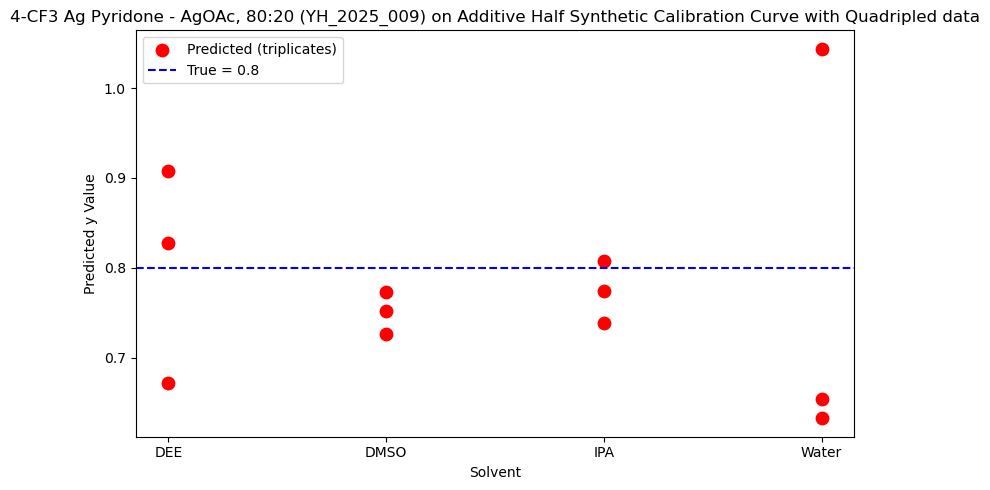


Triplicate-level results saved to YH_2025_009_grouped_triplicates_results.csv


In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error

root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])[:33]
y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

alphas = np.arange(0.1, 0.5, 0.1)
n_components = 5
true_y = 0.8

def load_spectrum(file_path):
    """Load 2nd column of CSV as spectrum."""
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def synthesize_spectrum(calib, solvent, alpha):
    """Add solvent contamination (100% + α×solvent)."""
    return calib + alpha * solvent

calib_rows = []
for file, y_val in zip(calib_files, y_values):
    spectrum = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spectrum, 0, y_val)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]
columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(calib_rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values
n_samples, n_features = X_calib.shape
print(f"Loaded {n_samples} calibration spectra with {n_features} features each.")

solvents = {}
for file in solvent_files:
    spec = load_spectrum(os.path.join(solvent_dir, file))
    if len(spec) != n_features:
        spec = np.interp(np.linspace(0, 1, n_features),
                         np.linspace(0, 1, len(spec)), spec)
        print(f"Interpolated {file} to {n_features} points")
    solvents[file.split('.')[0]] = spec

print(f"Loaded {len(solvents)} solvent spectra.\n")

X_augmented = [X_calib]
y_augmented = [y_calib]

for solvent_name, solvent_spec in solvents.items():
    print(f"Generating synthetic calibration data for {solvent_name}...")
    for alpha in alphas:
        X_synth = np.array([synthesize_spectrum(x_row, solvent_spec, alpha) for x_row in X_calib])
        X_augmented.append(X_synth)
        y_augmented.append(y_calib)

X_calib_all = np.vstack(X_augmented)
y_calib_all = np.concatenate(y_augmented)
print(f"Calibration dataset expanded to {len(X_calib_all)} samples (≈ 4× original with solvent contamination).\n")

pls = PLSRegression(n_components=n_components)
pls.fit(X_calib_all, y_calib_all)

test_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith('.csv')])
print(f"Testing {len(test_files)} files...\n")

predictions = []
maes = []

for test_file in test_files:
    test_spec = load_spectrum(os.path.join(test_dir, test_file))[:n_features]
    y_pred = float(pls.predict(test_spec.reshape(1, -1))[0])
    mae = mean_absolute_error([true_y], [y_pred])
    
    predictions.append((test_file, y_pred))
    maes.append(mae)
    
    print(f"Prediction for {test_file}: y = {y_pred:.4f}, MAE = {mae:.6f}")

print(f"\nAverage MAE across all test files: {np.mean(maes):.6f}")

solvent_labels = ['DEE', 'DMSO', 'IPA', 'Water']
x_positions = np.repeat(np.arange(len(solvent_labels)), 3)
y_values_plot = [p[1] for p in predictions]

plt.figure(figsize=(8, 5))
plt.scatter(x_positions, y_values_plot, color='red', s=80, label='Predicted (triplicates)')
plt.axhline(y=true_y, color='blue', linestyle='--', label=f'True = {true_y}')
plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y Value')
plt.title('4-CF3 Ag Pyridone - AgOAc, 80:20 (YH_2025_009) on Additive Half Synthetic Calibration Curve with Quadripled data')
plt.legend()
plt.tight_layout()
plt.show()

results_df = pd.DataFrame({
    'Test_File': [p[0] for p in predictions],
    'Predicted_y': [p[1] for p in predictions],
    'MAE': maes
})
results_df.to_csv('YH_2025_009_grouped_triplicates_results.csv', index=False)
print("\nTriplicate-level results saved to YH_2025_009_grouped_triplicates_results.csv")

Found 12 test files
YH_2025_009_DEE_A.CSV: y=0.7735, MAE=0.026532
YH_2025_009_DEE_B.CSV: y=0.8807, MAE=0.080711
YH_2025_009_DEE_C.CSV: y=0.9380, MAE=0.138039
YH_2025_009_DMSO_A.CSV: y=0.8121, MAE=0.012123
YH_2025_009_DMSO_B.CSV: y=0.9043, MAE=0.104254
YH_2025_009_DMSO_C.CSV: y=0.8485, MAE=0.048510
YH_2025_009_IPA_A.CSV: y=0.8579, MAE=0.057872
YH_2025_009_IPA_B.CSV: y=0.8292, MAE=0.029176
YH_2025_009_IPA_C.CSV: y=0.8658, MAE=0.065755
YH_2025_009_Water_A.CSV: y=0.6118, MAE=0.188188
YH_2025_009_Water_B.CSV: y=0.6720, MAE=0.127996
YH_2025_009_Water_C.CSV: y=0.7725, MAE=0.027489

Average MAE: 0.075554


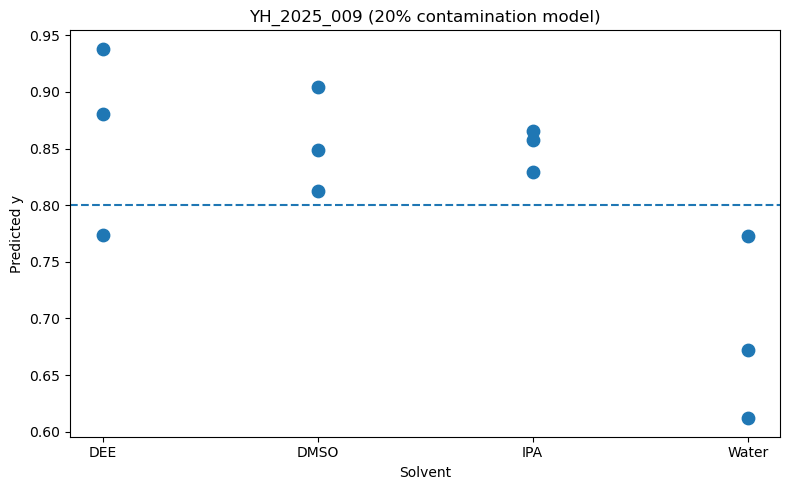

In [42]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

#SETTINGS
n_components = 5
true_y = 0.8
alphas = np.arange(0.05, 0.25, 0.05)  # up to 20%

calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])[:33]

y_values = [
    0.1,0.1,0.1,0,0,0,1,1,1,0.9,0.9,0.9,
    0.8,0.8,0.8,0.7,0.7,0.7,0.6,0.6,0.6,
    0.5,0.5,0.5,0.4,0.4,0.4,0.3,0.3,0.3,
    0.2,0.2,0.2
]

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

#FUNCTIONS
def load_spectrum(file_path):
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def synthesize_spectrum(calib, solvent, alpha):
    contaminated = calib + alpha * solvent
    return contaminated / (1 + alpha)

#LOAD CALIBRATION
calib_rows = []
for file, y_val in zip(calib_files, y_values):
    spectrum = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spectrum, 0, y_val)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]

columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(calib_rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values

solvents = {}
for file in solvent_files:
    spec = load_spectrum(os.path.join(solvent_dir, file))
    if len(spec) != X_calib.shape[1]:
        spec = np.interp(np.linspace(0,1,X_calib.shape[1]),
                         np.linspace(0,1,len(spec)), spec)
    solvents[file.split('.')[0]] = spec

# AUGMENTATION
X_augmented = [X_calib]
y_augmented = [y_calib]

for solvent_name, solvent_spec in solvents.items():
    for alpha in alphas:
        X_synth = np.array([
            synthesize_spectrum(x, solvent_spec, alpha)
            for x in X_calib
        ])
        X_augmented.append(X_synth)
        y_augmented.append(y_calib)

X_all = np.vstack(X_augmented)
y_all = np.concatenate(y_augmented)

scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

#MODEL
pls = PLSRegression(n_components=n_components)
pls.fit(X_all_scaled, y_all)

# TEst
test_files = sorted([
    f for f in os.listdir(test_dir)
    if f.lower().endswith('.csv')
])

print(f"Found {len(test_files)} test files")

if len(test_files) == 0:
    raise ValueError(f"No CSV test files found in: {test_dir}")

predictions = []
maes = []

for file in test_files:
    spec = load_spectrum(os.path.join(test_dir, file))[:X_calib.shape[1]]
    spec_scaled = scaler.transform(spec.reshape(1, -1))
    
    y_pred = float(pls.predict(spec_scaled)[0])
    mae = mean_absolute_error([true_y], [y_pred])
    
    predictions.append((file, y_pred))
    maes.append(mae)
    
    print(f"{file}: y={y_pred:.4f}, MAE={mae:.6f}")

if len(maes) > 0:
    print(f"\nAverage MAE: {np.mean(maes):.6f}")
else:
    print("\nNo predictions made — check test data.")

solvent_labels = ['DEE','DMSO','IPA','Water']
x_positions = []
y_plot = []

for file, y_pred in predictions:
    for i, solvent in enumerate(solvent_labels):
        if solvent in file:
            x_positions.append(i)
            y_plot.append(y_pred)
            break

plt.figure(figsize=(8,5))
plt.scatter(x_positions, y_plot, s=80)
plt.axhline(y=true_y, linestyle='--')

plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y')
plt.title('YH_2025_009 (20% contamination model)')
plt.tight_layout()
plt.show()

Loaded 33 calibration spectra with 7467 features each.

Interpolated YH_2025_007_DEE.csv to 7467 points
Interpolated YH_2025_007_DMSO.csv to 7467 points
Interpolated YH_2025_007_IPA.csv to 7467 points
Interpolated YH_2025_007_Water.csv to 7467 points
Loaded 4 solvent spectra.

Generating synthetic calibration data for YH_2025_007_DEE...
Generating synthetic calibration data for YH_2025_007_DMSO...
Generating synthetic calibration data for YH_2025_007_IPA...
Generating synthetic calibration data for YH_2025_007_Water...
Calibration dataset expanded to 561 samples.

Testing 12 files...

Prediction for YH_2025_009_DEE_A.CSV: y = 0.6214, MAE = 0.178581
Prediction for YH_2025_009_DEE_B.CSV: y = 0.7822, MAE = 0.017754
Prediction for YH_2025_009_DEE_C.CSV: y = 0.8650, MAE = 0.064989
Prediction for YH_2025_009_DMSO_A.CSV: y = 0.7035, MAE = 0.096482
Prediction for YH_2025_009_DMSO_B.CSV: y = 0.7238, MAE = 0.076207
Prediction for YH_2025_009_DMSO_C.CSV: y = 0.6762, MAE = 0.123760
Prediction for 

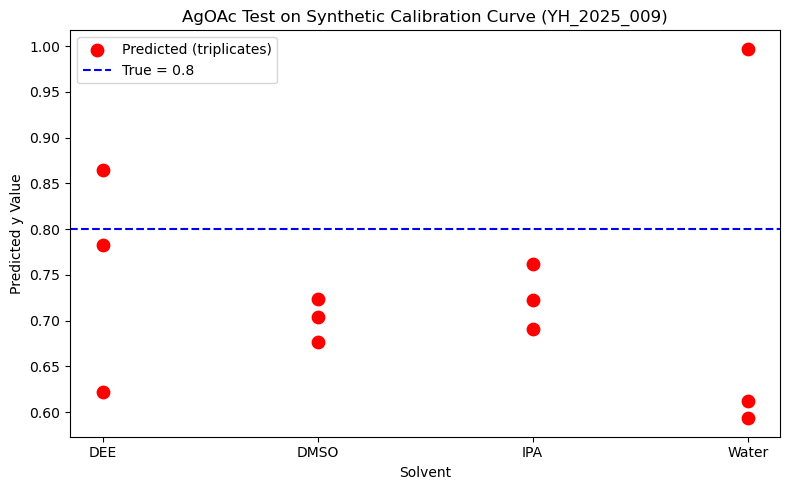


Triplicate-level results saved to YH_2025_009_AgOAc_results.csv


In [31]:
#Silver acetate and Pyrdione switch values
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error

root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_007/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])[:33]

y_values_ag_oac = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.1, 0.1, 0.1,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.6, 0.6, 0.6, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]

solvent_files = [
    'YH_2025_007_DEE.csv',
    'YH_2025_007_DMSO.csv',
    'YH_2025_007_IPA.csv',
    'YH_2025_007_Water.csv'
]

alphas = np.arange(0.1, 0.5, 0.1)
n_components = 5
true_y = 0.8

def load_spectrum(file_path):
    """Load 2nd column of CSV as spectrum."""
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def synthesize_spectrum(calib, solvent, alpha):
    """Add solvent contamination (100% + α×solvent)."""
    return calib + alpha * solvent

calib_rows = []
for file, y_val in zip(calib_files, y_values_ag_oac):
    spectrum = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spectrum, 0, y_val)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]
columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(calib_rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values
n_samples, n_features = X_calib.shape
print(f"Loaded {n_samples} calibration spectra with {n_features} features each.\n")

solvents = {}
for file in solvent_files:
    spec = load_spectrum(os.path.join(solvent_dir, file))
    if len(spec) != n_features:
        spec = np.interp(np.linspace(0, 1, n_features),
                         np.linspace(0, 1, len(spec)), spec)
        print(f"Interpolated {file} to {n_features} points")
    solvents[file.split('.')[0]] = spec

print(f"Loaded {len(solvents)} solvent spectra.\n")

X_augmented = [X_calib]
y_augmented = [y_calib]

for solvent_name, solvent_spec in solvents.items():
    print(f"Generating synthetic calibration data for {solvent_name}...")
    for alpha in alphas:
        X_synth = np.array([synthesize_spectrum(x_row, solvent_spec, alpha) for x_row in X_calib])
        X_augmented.append(X_synth)
        y_augmented.append(y_calib)

X_calib_all = np.vstack(X_augmented)
y_calib_all = np.concatenate(y_augmented)
print(f"Calibration dataset expanded to {len(X_calib_all)} samples.\n")

pls = PLSRegression(n_components=n_components)
pls.fit(X_calib_all, y_calib_all)

test_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith('.csv')])
print(f"Testing {len(test_files)} files...\n")

predictions = []
maes = []

for test_file in test_files:
    test_spec = load_spectrum(os.path.join(test_dir, test_file))[:n_features]
    y_pred = float(pls.predict(test_spec.reshape(1, -1))[0])
    mae = mean_absolute_error([true_y], [y_pred])
    
    predictions.append((test_file, y_pred))
    maes.append(mae)
    
    print(f"Prediction for {test_file}: y = {y_pred:.4f}, MAE = {mae:.6f}")

print(f"\nAverage MAE across all test files: {np.mean(maes):.6f}")

solvent_labels = ['DEE', 'DMSO', 'IPA', 'Water']
x_positions = np.repeat(np.arange(len(solvent_labels)), 3)
y_values_plot = [p[1] for p in predictions]

plt.figure(figsize=(8, 5))
plt.scatter(x_positions, y_values_plot, color='red', s=80, label='Predicted (triplicates)')
plt.axhline(y=true_y, color='blue', linestyle='--', label=f'True = {true_y}')
plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y Value')
plt.title('AgOAc Test on Synthetic Calibration Curve (YH_2025_009)')
plt.legend()
plt.tight_layout()
plt.show()

results_df = pd.DataFrame({
    'Test_File': [p[0] for p in predictions],
    'Predicted_y': [p[1] for p in predictions],
    'MAE': maes
})
results_df.to_csv('YH_2025_009_AgOAc_results.csv', index=False)
print("\nTriplicate-level results saved to YH_2025_009_AgOAc_results.csv")

Loaded 33 calibration spectra with 7467 features each.
Interpolated YH_2025_008_HFIP_A.csv to 7467 points
Interpolated YH_2025_008_HFIP_B.csv to 7467 points
Interpolated YH_2025_008_HFIP_C.csv to 7467 points
Interpolated YH_2025_008_DCE_A.csv to 7467 points
Interpolated YH_2025_008_DCE_B.csv to 7467 points
Interpolated YH_2025_008_DCE_C.csv to 7467 points
Interpolated YH_2025_008_Toluene_A.csv to 7467 points
Interpolated YH_2025_008_Toluene_B.csv to 7467 points
Interpolated YH_2025_008_Toluene_C.csv to 7467 points
Loaded 9 solvent spectra.

Generating synthetic calibration data for YH_2025_008_HFIP_A...
Generating synthetic calibration data for YH_2025_008_HFIP_B...
Generating synthetic calibration data for YH_2025_008_HFIP_C...
Generating synthetic calibration data for YH_2025_008_DCE_A...
Generating synthetic calibration data for YH_2025_008_DCE_B...
Generating synthetic calibration data for YH_2025_008_DCE_C...
Generating synthetic calibration data for YH_2025_008_Toluene_A...
Gener

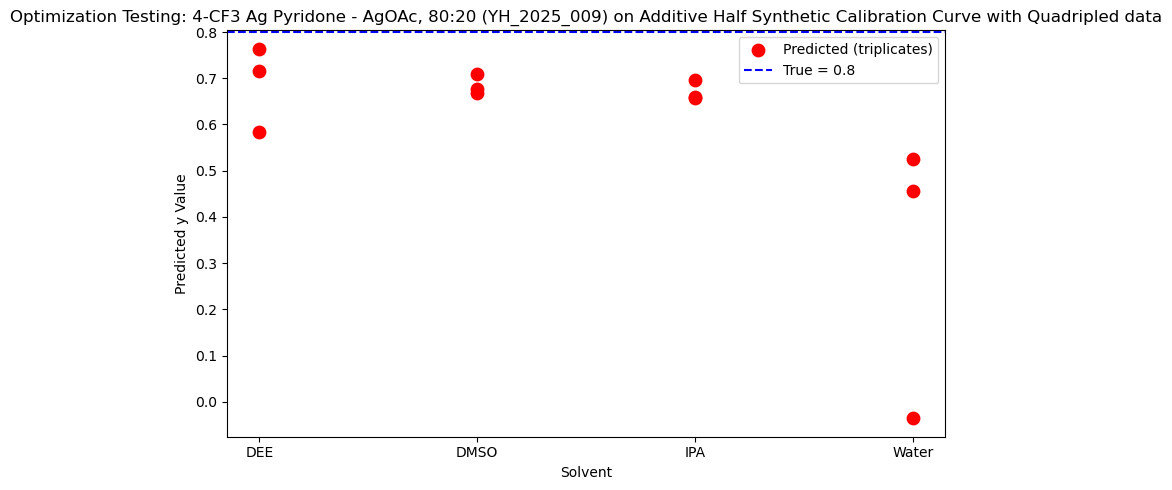

In [2]:
#Optimization Testing
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error

root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/' 
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_008/'
test_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

calib_files = sorted([f for f in os.listdir(root_calib) if f.lower().endswith('.csv')])[:33]
y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]

solvent_files = [
    'YH_2025_008_HFIP_A.csv',
    'YH_2025_008_HFIP_B.csv',
    'YH_2025_008_HFIP_C.csv',
    'YH_2025_008_DCE_A.csv',
    'YH_2025_008_DCE_B.csv',
    'YH_2025_008_DCE_C.csv',
    'YH_2025_008_Toluene_A.csv',
    'YH_2025_008_Toluene_B.csv',
    'YH_2025_008_Toluene_C.csv'
]

alphas = np.arange(0.1, 0.5, 0.1)
n_components = 5
true_y = 0.8

def load_spectrum(file_path):
    """Load 2nd column of CSV as spectrum."""
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def synthesize_spectrum(calib, solvent, alpha):
    """Add solvent contamination (100% + α×solvent)."""
    return calib + alpha * solvent

calib_rows = []
for file, y_val in zip(calib_files, y_values):
    spectrum = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spectrum, 0, y_val)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]
columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(calib_rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values
n_samples, n_features = X_calib.shape
print(f"Loaded {n_samples} calibration spectra with {n_features} features each.")

solvents = {}
for file in solvent_files:
    spec = load_spectrum(os.path.join(solvent_dir, file))
    if len(spec) != n_features:
        spec = np.interp(np.linspace(0, 1, n_features),
                         np.linspace(0, 1, len(spec)), spec)
        print(f"Interpolated {file} to {n_features} points")
    solvents[file.split('.')[0]] = spec

print(f"Loaded {len(solvents)} solvent spectra.\n")

X_augmented = [X_calib]
y_augmented = [y_calib]

for solvent_name, solvent_spec in solvents.items():
    print(f"Generating synthetic calibration data for {solvent_name}...")
    for alpha in alphas:
        X_synth = np.array([synthesize_spectrum(x_row, solvent_spec, alpha) for x_row in X_calib])
        X_augmented.append(X_synth)
        y_augmented.append(y_calib)

X_calib_all = np.vstack(X_augmented)
y_calib_all = np.concatenate(y_augmented)
print(f"Calibration dataset expanded to {len(X_calib_all)} samples (≈ 4× original with solvent contamination).\n")

pls = PLSRegression(n_components=n_components)
pls.fit(X_calib_all, y_calib_all)

test_files = sorted([f for f in os.listdir(test_dir) if f.lower().endswith('.csv')])
print(f"Testing {len(test_files)} files...\n")

predictions = []
maes = []

for test_file in test_files:
    test_spec = load_spectrum(os.path.join(test_dir, test_file))[:n_features]
    y_pred = float(pls.predict(test_spec.reshape(1, -1))[0])
    mae = mean_absolute_error([true_y], [y_pred])
    
    predictions.append((test_file, y_pred))
    maes.append(mae)
    
    print(f"Prediction for {test_file}: y = {y_pred:.4f}, MAE = {mae:.6f}")

print(f"\nAverage MAE across all test files: {np.mean(maes):.6f}")

solvent_labels = ['DEE', 'DMSO', 'IPA', 'Water']
x_positions = np.repeat(np.arange(len(solvent_labels)), 3)
y_values_plot = [p[1] for p in predictions]

plt.figure(figsize=(8, 5))
plt.scatter(x_positions, y_values_plot, color='red', s=80, label='Predicted (triplicates)')
plt.axhline(y=true_y, color='blue', linestyle='--', label=f'True = {true_y}')
plt.xticks(range(len(solvent_labels)), solvent_labels)
plt.xlabel('Solvent')
plt.ylabel('Predicted y Value')
plt.title('Optimization Testing: 4-CF3 Ag Pyridone - AgOAc, 80:20 (YH_2025_009) on Additive Half Synthetic Calibration Curve with Quadripled data')
plt.legend()
plt.tight_layout()
plt.show()

results_df = pd.DataFrame({
    'Test_File': [p[0] for p in predictions],
    'Predicted_y': [p[1] for p in predictions],
    'MAE': maes
})

Loaded 33 calibration spectra with 7467 features each.
Interpolated YH_2025_008_HFIP_A.csv to 7467 points
Interpolated YH_2025_008_HFIP_B.csv to 7467 points
Interpolated YH_2025_008_HFIP_C.csv to 7467 points
Interpolated YH_2025_008_DCE_A.csv to 7467 points
Interpolated YH_2025_008_DCE_B.csv to 7467 points
Interpolated YH_2025_008_DCE_C.csv to 7467 points
Interpolated YH_2025_008_Toluene_A.csv to 7467 points
Interpolated YH_2025_008_Toluene_B.csv to 7467 points
Interpolated YH_2025_008_Toluene_C.csv to 7467 points
Loaded 9 solvent spectra.

Generating synthetic calibration data for YH_2025_008_HFIP_A...
Generating synthetic calibration data for YH_2025_008_HFIP_B...
Generating synthetic calibration data for YH_2025_008_HFIP_C...
Generating synthetic calibration data for YH_2025_008_DCE_A...
Generating synthetic calibration data for YH_2025_008_DCE_B...
Generating synthetic calibration data for YH_2025_008_DCE_C...
Generating synthetic calibration data for YH_2025_008_Toluene_A...
Gener

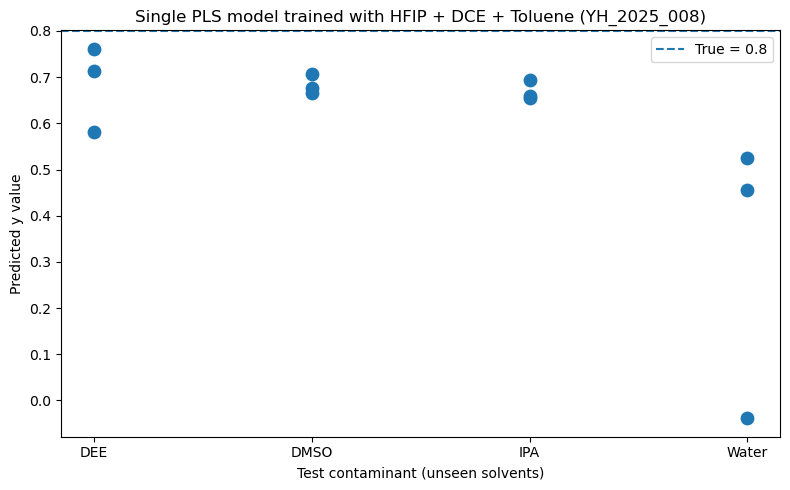

In [14]:
# Optimization Testing (Frist trial??)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error


root_calib = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_008/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

calib_files = sorted(
    [f for f in os.listdir(root_calib) if f.lower().endswith('.csv')]
)[:33]

y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]

solvent_files = [
    'YH_2025_008_HFIP_A.csv',
    'YH_2025_008_HFIP_B.csv',
    'YH_2025_008_HFIP_C.csv',
    'YH_2025_008_DCE_A.csv',
    'YH_2025_008_DCE_B.csv',
    'YH_2025_008_DCE_C.csv',
    'YH_2025_008_Toluene_A.csv',
    'YH_2025_008_Toluene_B.csv',
    'YH_2025_008_Toluene_C.csv'
]


alphas = np.arange(0.1, 0.5, 0.1)
n_components = 5
true_y = 0.8

def load_spectrum(file_path):
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values


def synthesize_spectrum(calib, solvent, alpha):
    return calib + alpha * solvent

calib_rows = []

for file, y_val in zip(calib_files, y_values):
    spectrum = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spectrum, 0, y_val)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]

columns = ['y'] + [f'x{i+1}' for i in range(min_len - 1)]
calib_df = pd.DataFrame(calib_rows, columns=columns)

y_calib = calib_df['y'].values
X_calib = calib_df.drop('y', axis=1).values

n_samples, n_features = X_calib.shape
print(f"Loaded {n_samples} calibration spectra with {n_features} features each.")

solvents = {}

for file in solvent_files:
    spec = load_spectrum(os.path.join(solvent_dir, file))

    if len(spec) != n_features:
        spec = np.interp(
            np.linspace(0, 1, n_features),
            np.linspace(0, 1, len(spec)),
            spec
        )
        print(f"Interpolated {file} to {n_features} points")

    solvents[file.replace('.csv', '')] = spec

print(f"Loaded {len(solvents)} solvent spectra.\n")


X_augmented = [X_calib]
y_augmented = [y_calib]

for solvent_name, solvent_spec in solvents.items():
    print(f"Generating synthetic calibration data for {solvent_name}...")
    for alpha in alphas:
        X_synth = np.array([
            synthesize_spectrum(x_row, solvent_spec, alpha)
            for x_row in X_calib
        ])
        X_augmented.append(X_synth)
        y_augmented.append(y_calib)

X_calib_all = np.vstack(X_augmented)
y_calib_all = np.concatenate(y_augmented)

print(f"\nCalibration dataset expanded to {len(X_calib_all)} samples.\n")


pls = PLSRegression(n_components=n_components)
pls.fit(X_calib_all, y_calib_all)

test_files = sorted(
    [f for f in os.listdir(test_dir) if f.lower().endswith('.csv')]
)

print(f"Testing {len(test_files)} files...\n")

predictions = []
maes = []

for test_file in test_files:

    test_spec = load_spectrum(
        os.path.join(test_dir, test_file)
    )

    if len(test_spec) != n_features:
        test_spec = np.interp(
            np.linspace(0, 1, n_features),
            np.linspace(0, 1, len(test_spec)),
            test_spec
        )

    y_pred = float(pls.predict(test_spec.reshape(1, -1))[0])
    mae = mean_absolute_error([true_y], [y_pred])

    predictions.append((test_file, y_pred))
    maes.append(mae)

    print(f"Prediction for {test_file}: y = {y_pred:.4f}, MAE = {mae:.6f}")

print(f"\nAverage MAE across all test files: {np.mean(maes):.6f}")


labels = []
y_values_plot = []

for fname, ypred in predictions:
    # YH_2025_009_DEE_A.CSV  ->  DEE
    solvent = fname.split('_')[3]
    labels.append(solvent)
    y_values_plot.append(ypred)

# preserve file order
unique_solvents = list(dict.fromkeys(labels))

x_map = {s: i for i, s in enumerate(unique_solvents)}
x_positions = [x_map[s] for s in labels]

plt.figure(figsize=(8, 5))
plt.scatter(x_positions, y_values_plot, s=80)

plt.axhline(y=true_y, linestyle='--', label=f'True = {true_y}')
plt.xticks(range(len(unique_solvents)), unique_solvents)

plt.xlabel('Test contaminant (unseen solvents)')
plt.ylabel('Predicted y value')
plt.title('Single PLS model trained with HFIP + DCE + Toluene (YH_2025_008)')
plt.legend()
plt.tight_layout()
plt.show()

Loaded 33 calibration spectra with 7467 features each.
Loaded and averaged 3 solvent spectra.

Generating synthetic data for HFIP...
Generating synthetic data for DCE...
Generating synthetic data for Toluene...

Calibration expanded to 429 samples.

n_components =  2 | CV MAE = 0.1354
n_components =  3 | CV MAE = 0.1311
n_components =  4 | CV MAE = 0.1151
n_components =  5 | CV MAE = 0.0905
n_components =  6 | CV MAE = 0.0885
n_components =  7 | CV MAE = 0.0524
n_components =  8 | CV MAE = 0.0436
n_components =  9 | CV MAE = 0.0402
n_components = 10 | CV MAE = 0.0361
n_components = 11 | CV MAE = 0.0245
n_components = 12 | CV MAE = 0.0161
n_components = 13 | CV MAE = 0.0103
n_components = 14 | CV MAE = 0.0062

Selected n_components = 14 (CV MAE = 0.0062)

Testing 12 files...

YH_2025_009_DEE_A.CSV: y = 0.9630 | MAE = 0.1630
YH_2025_009_DEE_B.CSV: y = 1.2355 | MAE = 0.4355
YH_2025_009_DEE_C.CSV: y = 1.1642 | MAE = 0.3642
YH_2025_009_DMSO_A.CSV: y = 1.1707 | MAE = 0.3707
YH_2025_009_DMSO_

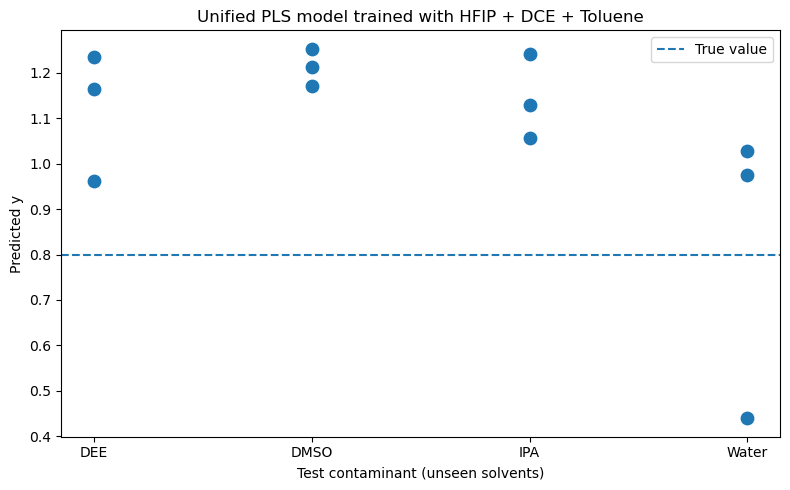

In [15]:
# Optimization Testing (First trial)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict


root_calib  = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_008/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'


calib_files = sorted(
    [f for f in os.listdir(root_calib) if f.lower().endswith('.csv')]
)[:33]

y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]


solvent_groups = {
    'HFIP': [
        'YH_2025_008_HFIP_A.csv',
        'YH_2025_008_HFIP_B.csv',
        'YH_2025_008_HFIP_C.csv'
    ],
    'DCE': [
        'YH_2025_008_DCE_A.csv',
        'YH_2025_008_DCE_B.csv',
        'YH_2025_008_DCE_C.csv'
    ],
    'Toluene': [
        'YH_2025_008_Toluene_A.csv',
        'YH_2025_008_Toluene_B.csv',
        'YH_2025_008_Toluene_C.csv'
    ]
}

alphas = np.arange(0.1, 0.5, 0.1)
true_y = 0.8

def load_spectrum(file_path):
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def interpolate(spec, target_len):
    return np.interp(
        np.linspace(0, 1, target_len),
        np.linspace(0, 1, len(spec)),
        spec
    )


def synthesize_spectrum(calib, solvent, alpha):
    return calib + alpha * solvent

calib_rows = []

for file, y in zip(calib_files, y_values):
    spec = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spec, 0, y)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]

X_calib = np.array([r[1:] for r in calib_rows])
y_calib = np.array(y_values)

n_samples, n_features = X_calib.shape
print(f"Loaded {n_samples} calibration spectra with {n_features} features each.")


solvents = {}

for name, files in solvent_groups.items():
    specs = []
    for f in files:
        spec = load_spectrum(os.path.join(solvent_dir, f))
        if len(spec) != n_features:
            spec = interpolate(spec, n_features)
        specs.append(spec)
    solvents[name] = np.mean(specs, axis=0)

print(f"Loaded and averaged {len(solvents)} solvent spectra.\n")

X_aug = [X_calib]
y_aug = [y_calib]

for solvent_name, solvent_spec in solvents.items():
    print(f"Generating synthetic data for {solvent_name}...")
    for alpha in alphas:
        X_aug.append(np.array([
            synthesize_spectrum(x, solvent_spec, alpha)
            for x in X_calib
        ]))
        y_aug.append(y_calib)

X_all = np.vstack(X_aug)
y_all = np.concatenate(y_aug)

print(f"\nCalibration expanded to {len(X_all)} samples.\n")


scaler = StandardScaler()
X_all = scaler.fit_transform(X_all)

best_k = None
best_mae = np.inf

for k in range(2, 15):
    pls = PLSRegression(n_components=k)
    y_cv = cross_val_predict(pls, X_all, y_all, cv=5)
    mae = mean_absolute_error(y_all, y_cv)
    print(f"n_components = {k:2d} | CV MAE = {mae:.4f}")
    if mae < best_mae:
        best_mae = mae
        best_k = k

print(f"\nSelected n_components = {best_k} (CV MAE = {best_mae:.4f})\n")

pls = PLSRegression(n_components=best_k)
pls.fit(X_all, y_all)

test_files = sorted(
    [f for f in os.listdir(test_dir) if f.lower().endswith('.csv')]
)

predictions, maes = [], []

print(f"Testing {len(test_files)} files...\n")

for f in test_files:
    spec = load_spectrum(os.path.join(test_dir, f))
    if len(spec) != n_features:
        spec = interpolate(spec, n_features)
    spec = scaler.transform(spec.reshape(1, -1))

    y_pred = float(pls.predict(spec)[0])
    mae = abs(y_pred - true_y)

    predictions.append((f, y_pred))
    maes.append(mae)

    print(f"{f}: y = {y_pred:.4f} | MAE = {mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")

labels = [f.split('_')[3] for f, _ in predictions]
y_vals = [y for _, y in predictions]

unique = list(dict.fromkeys(labels))
x_map = {s: i for i, s in enumerate(unique)}
x_pos = [x_map[s] for s in labels]

plt.figure(figsize=(8, 5))
plt.scatter(x_pos, y_vals, s=80)
plt.axhline(true_y, linestyle='--', label='True value')

plt.xticks(range(len(unique)), unique)
plt.xlabel('Test contaminant (unseen solvents)')
plt.ylabel('Predicted y')
plt.title('Unified PLS model trained with HFIP + DCE + Toluene')
plt.legend()
plt.tight_layout()
plt.show()

Loaded 33 calibration spectra with 7467 features each.
Loaded and averaged 3 solvent spectra.

Generating contamination for HFIP...
Generating contamination for DCE...
Generating contamination for Toluene...

Calibration expanded to 429 samples.

n_components =  2 | CV MAE = 0.0699
n_components =  3 | CV MAE = 0.0447
n_components =  4 | CV MAE = 0.0184
n_components =  5 | CV MAE = 0.0126
n_components =  6 | CV MAE = 0.0085
n_components =  7 | CV MAE = 0.0038

Selected n_components = 7 (CV MAE = 0.0038)

Testing 12 files...

YH_2025_009_DEE_A.CSV: y = 0.8147 | MAE = 0.0147
YH_2025_009_DEE_B.CSV: y = 0.8729 | MAE = 0.0729
YH_2025_009_DEE_C.CSV: y = 0.9046 | MAE = 0.1046
YH_2025_009_DMSO_A.CSV: y = 0.7190 | MAE = 0.0810
YH_2025_009_DMSO_B.CSV: y = 0.7924 | MAE = 0.0076
YH_2025_009_DMSO_C.CSV: y = 0.7661 | MAE = 0.0339
YH_2025_009_IPA_A.CSV: y = 0.7163 | MAE = 0.0837
YH_2025_009_IPA_B.CSV: y = 0.7083 | MAE = 0.0917
YH_2025_009_IPA_C.CSV: y = 0.7458 | MAE = 0.0542
YH_2025_009_Water_A.CSV: y

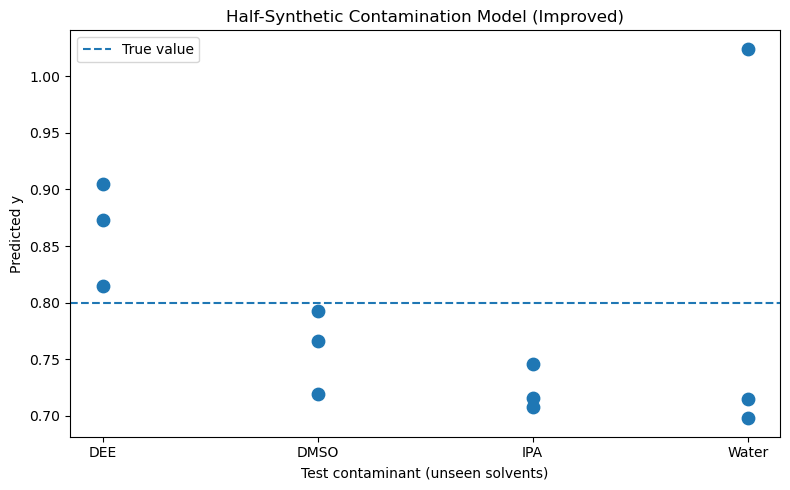

In [2]:
# Optimization Testing (not final)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict

from scipy.signal import savgol_filter

root_calib  = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_008/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'


alphas = np.arange(0.1, 0.5, 0.1)
true_y = 0.8

calib_files = sorted(
    [f for f in os.listdir(root_calib) if f.lower().endswith('.csv')]
)[:33]

y_values = [
    0.1, 0.1, 0.1, 0, 0, 0, 1, 1, 1, 0.9, 0.9, 0.9,
    0.8, 0.8, 0.8, 0.7, 0.7, 0.7, 0.6, 0.6, 0.6,
    0.5, 0.5, 0.5, 0.4, 0.4, 0.4, 0.3, 0.3, 0.3,
    0.2, 0.2, 0.2
]

solvent_groups = {
    'HFIP': [
        'YH_2025_008_HFIP_A.csv',
        'YH_2025_008_HFIP_B.csv',
        'YH_2025_008_HFIP_C.csv'
    ],
    'DCE': [
        'YH_2025_008_DCE_A.csv',
        'YH_2025_008_DCE_B.csv',
        'YH_2025_008_DCE_C.csv'
    ],
    'Toluene': [
        'YH_2025_008_Toluene_A.csv',
        'YH_2025_008_Toluene_B.csv',
        'YH_2025_008_Toluene_C.csv'
    ]
}

def load_spectrum(file_path):
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:, 1].values

def interpolate(spec, target_len):
    return np.interp(
        np.linspace(0, 1, target_len),
        np.linspace(0, 1, len(spec)),
        spec
    )

def normalize(x):
    return x / np.linalg.norm(x)

def preprocess(x):
    x = normalize(x)
    x = savgol_filter(x, window_length=15, polyorder=3, deriv=2)
    return x

calib_rows = []

for file, y in zip(calib_files, y_values):

    spec = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spec, 0, y)
    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]

X_calib = np.array([r[1:] for r in calib_rows])
y_calib = np.array(y_values)

n_samples, n_features = X_calib.shape

print(f"Loaded {n_samples} calibration spectra with {n_features} features each.")

X_calib = np.array([preprocess(x) for x in X_calib])

calib_mean = X_calib.mean(axis=0)


solvents = {}

for name, files in solvent_groups.items():

    specs = []

    for f in files:

        spec = load_spectrum(os.path.join(solvent_dir, f))

        if len(spec) != n_features:
            spec = interpolate(spec, n_features)

        spec = preprocess(spec)

        specs.append(spec)

    solvents[name] = np.mean(specs, axis=0)

print(f"Loaded and averaged {len(solvents)} solvent spectra.\n")


X_aug = [X_calib]
y_aug = [y_calib]

for solvent_name, solvent_spec in solvents.items():

    print(f"Generating contamination for {solvent_name}...")

    for alpha in alphas:

        contaminated = []

        for x in X_calib:

            # contamination relative to calibration mean
            contamination = solvent_spec - calib_mean

            synthetic = x + alpha * contamination

            contaminated.append(synthetic)

        X_aug.append(np.array(contaminated))
        y_aug.append(y_calib)

X_all = np.vstack(X_aug)
y_all = np.concatenate(y_aug)

print(f"\nCalibration expanded to {len(X_all)} samples.\n")

scaler = StandardScaler()
X_all = scaler.fit_transform(X_all)

best_k = None
best_mae = np.inf

for k in range(2, 8):

    pls = PLSRegression(n_components=k)

    y_cv = cross_val_predict(pls, X_all, y_all, cv=5)

    mae = mean_absolute_error(y_all, y_cv)

    print(f"n_components = {k:2d} | CV MAE = {mae:.4f}")

    if mae < best_mae:

        best_mae = mae
        best_k = k

print(f"\nSelected n_components = {best_k} (CV MAE = {best_mae:.4f})\n")

pls = PLSRegression(n_components=best_k)
pls.fit(X_all, y_all)

test_files = sorted(
    [f for f in os.listdir(test_dir) if f.lower().endswith('.csv')]
)

predictions = []
maes = []

print(f"Testing {len(test_files)} files...\n")

for f in test_files:

    spec = load_spectrum(os.path.join(test_dir, f))

    if len(spec) != n_features:
        spec = interpolate(spec, n_features)

    spec = preprocess(spec)

    spec = scaler.transform(spec.reshape(1, -1))

    y_pred = float(pls.predict(spec)[0])

    mae = abs(y_pred - true_y)

    predictions.append((f, y_pred))
    maes.append(mae)

    print(f"{f}: y = {y_pred:.4f} | MAE = {mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")


labels = [f.split('_')[3] for f, _ in predictions]
y_vals = [y for _, y in predictions]

unique = list(dict.fromkeys(labels))

x_map = {s: i for i, s in enumerate(unique)}

x_pos = [x_map[s] for s in labels]

plt.figure(figsize=(8,5))

plt.scatter(x_pos, y_vals, s=80)

plt.axhline(true_y, linestyle='--', label='True value')

plt.xticks(range(len(unique)), unique)

plt.xlabel('Test contaminant (unseen solvents)')
plt.ylabel('Predicted y')

plt.title('Half-Synthetic Contamination Model (Improved)')

plt.legend()

plt.tight_layout()

plt.show()


df = pd.DataFrame({
    "Test_File":[p[0] for p in predictions],
    "Predicted_y":[p[1] for p in predictions],
    "MAE":maes
})

Loaded 33 calibration spectra with 7467 features each.
Loaded and averaged 3 solvent spectra.

Generating contamination for HFIP...
Generating contamination for DCE...
Generating contamination for Toluene...

Calibration expanded to 429 samples.

Using fixed n_components = 5

Testing 12 files...

YH_2025_009_DEE_A.CSV: y = 0.8100 | MAE = 0.0100
YH_2025_009_DEE_B.CSV: y = 0.8655 | MAE = 0.0655
YH_2025_009_DEE_C.CSV: y = 0.9035 | MAE = 0.1035
YH_2025_009_DMSO_A.CSV: y = 0.7145 | MAE = 0.0855
YH_2025_009_DMSO_B.CSV: y = 0.7876 | MAE = 0.0124
YH_2025_009_DMSO_C.CSV: y = 0.7597 | MAE = 0.0403
YH_2025_009_IPA_A.CSV: y = 0.7126 | MAE = 0.0874
YH_2025_009_IPA_B.CSV: y = 0.7039 | MAE = 0.0961
YH_2025_009_IPA_C.CSV: y = 0.7390 | MAE = 0.0610
YH_2025_009_Water_A.CSV: y = 0.6884 | MAE = 0.1116
YH_2025_009_Water_B.CSV: y = 0.7067 | MAE = 0.0933
YH_2025_009_Water_C.CSV: y = 1.0253 | MAE = 0.2253

Average MAE: 0.0827


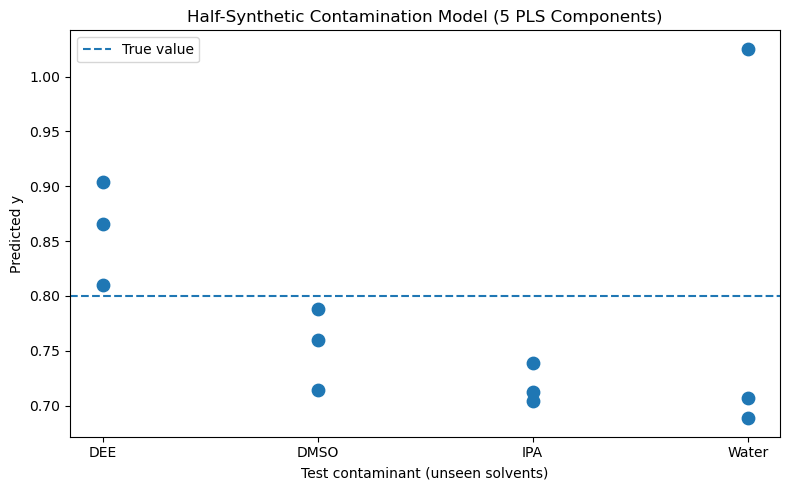

In [1]:
# Optimization Testing

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

from scipy.signal import savgol_filter


root_calib  = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_003/'
solvent_dir = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_008/'
test_dir    = '/Users/yoelhan/Documents/ChemResearch/ir_data/YH_2025_009/'

alphas = np.arange(0.1, 0.5, 0.1)
true_y = 0.8
n_components = 5


calib_files = sorted(
    [f for f in os.listdir(root_calib) if f.lower().endswith('.csv')]
)[:33]

y_values = [
    0.1,0.1,0.1,0,0,0,1,1,1,0.9,0.9,0.9,
    0.8,0.8,0.8,0.7,0.7,0.7,0.6,0.6,0.6,
    0.5,0.5,0.5,0.4,0.4,0.4,0.3,0.3,0.3,
    0.2,0.2,0.2
]


solvent_groups = {
    'HFIP': [
        'YH_2025_008_HFIP_A.csv',
        'YH_2025_008_HFIP_B.csv',
        'YH_2025_008_HFIP_C.csv'
    ],
    'DCE': [
        'YH_2025_008_DCE_A.csv',
        'YH_2025_008_DCE_B.csv',
        'YH_2025_008_DCE_C.csv'
    ],
    'Toluene': [
        'YH_2025_008_Toluene_A.csv',
        'YH_2025_008_Toluene_B.csv',
        'YH_2025_008_Toluene_C.csv'
    ]
}


def load_spectrum(file_path):
    data = pd.read_csv(file_path, header=None, skiprows=1)
    return data.iloc[:,1].values


def interpolate(spec, target_len):
    return np.interp(
        np.linspace(0,1,target_len),
        np.linspace(0,1,len(spec)),
        spec
    )


def normalize(x):
    return x / np.linalg.norm(x)


def preprocess(x):
    x = normalize(x)
    x = savgol_filter(x, window_length=15, polyorder=3, deriv=2)
    return x


calib_rows = []

for file, y in zip(calib_files, y_values):

    spec = load_spectrum(os.path.join(root_calib, file))
    row = np.insert(spec,0,y)

    calib_rows.append(row)

min_len = min(len(r) for r in calib_rows)
calib_rows = [r[:min_len] for r in calib_rows]

X_calib = np.array([r[1:] for r in calib_rows])
y_calib = np.array(y_values)

n_samples, n_features = X_calib.shape

print(f"Loaded {n_samples} calibration spectra with {n_features} features each.")

X_calib = np.array([preprocess(x) for x in X_calib])

calib_mean = X_calib.mean(axis=0)


solvents = {}

for name, files in solvent_groups.items():

    specs = []

    for f in files:

        spec = load_spectrum(os.path.join(solvent_dir,f))

        if len(spec) != n_features:
            spec = interpolate(spec,n_features)

        spec = preprocess(spec)

        specs.append(spec)

    solvents[name] = np.mean(specs,axis=0)

print(f"Loaded and averaged {len(solvents)} solvent spectra.\n")


X_aug = [X_calib]
y_aug = [y_calib]

for solvent_name, solvent_spec in solvents.items():

    print(f"Generating contamination for {solvent_name}...")

    contamination = solvent_spec - calib_mean

    for alpha in alphas:

        contaminated = []

        for x in X_calib:

            synthetic = x + alpha * contamination
            contaminated.append(synthetic)

        X_aug.append(np.array(contaminated))
        y_aug.append(y_calib)

X_all = np.vstack(X_aug)
y_all = np.concatenate(y_aug)

print(f"\nCalibration expanded to {len(X_all)} samples.\n")

scaler = StandardScaler()
X_all = scaler.fit_transform(X_all)

pls = PLSRegression(n_components=n_components)
pls.fit(X_all,y_all)

print(f"Using fixed n_components = {n_components}\n")


test_files = sorted(
    [f for f in os.listdir(test_dir) if f.lower().endswith('.csv')]
)

predictions = []
maes = []

print(f"Testing {len(test_files)} files...\n")

for f in test_files:

    spec = load_spectrum(os.path.join(test_dir,f))

    if len(spec) != n_features:
        spec = interpolate(spec,n_features)

    spec = preprocess(spec)

    spec = scaler.transform(spec.reshape(1,-1))

    y_pred = float(pls.predict(spec)[0])

    mae = abs(y_pred - true_y)

    predictions.append((f,y_pred))
    maes.append(mae)

    print(f"{f}: y = {y_pred:.4f} | MAE = {mae:.4f}")

print(f"\nAverage MAE: {np.mean(maes):.4f}")


labels = [f.split('_')[3] for f,_ in predictions]
y_vals = [y for _,y in predictions]

unique = list(dict.fromkeys(labels))
x_map = {s:i for i,s in enumerate(unique)}

x_pos = [x_map[s] for s in labels]

plt.figure(figsize=(8,5))

plt.scatter(x_pos,y_vals,s=80)

plt.axhline(true_y,linestyle='--',label='True value')

plt.xticks(range(len(unique)),unique)

plt.xlabel('Test contaminant (unseen solvents)')
plt.ylabel('Predicted y')

plt.title('Half-Synthetic Contamination Model (5 PLS Components)')

plt.legend()

plt.tight_layout()

plt.show()

df = pd.DataFrame({
    "Test_File":[p[0] for p in predictions],
    "Predicted_y":[p[1] for p in predictions],
    "MAE":maes
})